In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
# import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

In [5]:
all_available = pd.read_csv('E:\Manoj_honors\Merged_Data(Spatio-temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_NO2(STC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


764702


C:\Users\USER1\AppData\Local\Temp\ipykernel_21480\2411388861.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 242.64 ± 5.87
Mean Absolute Error: 8.33 ± 0.05
R^2 Score: 0.8 ± 0.0
Mean Absolute Percentage Error: 53.26% ± 3.38%
Normalized RMSE: 0.0312 ± 0.0004


In [6]:
# Load the dataset
all_available = pd.read_csv('E:\Manoj_honors\Merged_Data(Spatio-temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['Ozone']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_Ozone(STC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


764702


C:\Users\USER1\AppData\Local\Temp\ipykernel_21480\118362833.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 185.13 ± 2.04
Mean Absolute Error: 7.73 ± 0.03
R^2 Score: 0.84 ± 0.0
Mean Absolute Percentage Error: 86.64% ± 1.63%
Normalized RMSE: 0.068 ± 0.0004


In [7]:
# Load the dataset
all_available = pd.read_csv('E:\Manoj_honors\Merged_Data(Spatio-temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','NO2','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['Ozone']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_Ozone(PCC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


764702


C:\Users\USER1\AppData\Local\Temp\ipykernel_21480\136628673.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 207.13 ± 1.73
Mean Absolute Error: 8.33 ± 0.04
R^2 Score: 0.82 ± 0.0
Mean Absolute Percentage Error: 103.57% ± 1.61%
Normalized RMSE: 0.072 ± 0.0003


In [9]:
# Load the dataset
all_available = pd.read_csv('E:\Manoj_honors\Merged_Data(Spatio-temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','Spatial_Avg_NO2','NO2_prev_day','NO2_prev_week']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_NO2(CC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


764702


C:\Users\USER1\AppData\Local\Temp\ipykernel_21480\3906404456.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 220.28 ± 4.07
Mean Absolute Error: 7.92 ± 0.03
R^2 Score: 0.82 ± 0.0
Mean Absolute Percentage Error: 53.35% ± 2.69%
Normalized RMSE: 0.0298 ± 0.0003


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5','NO2']]
y = all_available['Ozone']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_6640\1593479912.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_6640\1593479912.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 128)         │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,777 (483.50 KB)

 Trainable params: 123,777 (483.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.3907 - mae: 0.4051 - mse: 0.3907 - val_loss: 0.3214 - val_mae: 0.3535 - val_mse: 0.3214
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3449 - mae: 0.3744 - mse: 0.3449 - val_loss: 0.3094 - val_mae: 0.3487 - val_mse: 0.3094
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3318 - mae: 0.3661 - mse: 0.3318 - val_loss: 0.3006 - val_mae: 0.3366 - val_mse: 0.3006
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3220 - mae: 0.3600 - mse: 0.3220 - val_loss: 0.2862 - val_mae: 0.3397 - val_mse: 0.2862
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3140 - mae: 0.3551 - mse: 0.3140 - val_loss: 0.2691 - val_mae: 0.3253 - val_mse: 0.2691
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.3002 - mae: 0.3482 - mse: 0.3002 - val_loss: 0.2525 - val_mae: 0.3075 - val_mse: 0.2525
Epoch 7/50


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','NO2','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['Ozone']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_6640\1542382082.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_6640\1542382082.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,313 (489.50 KB)

 Trainable params: 125,313 (489.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - loss: 0.7963 - mae: 0.6293 - mse: 0.7963 - val_loss: 0.6954 - val_mae: 0.5776 - val_mse: 0.6954
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 0.7149 - mae: 0.5891 - mse: 0.7149 - val_loss: 0.6335 - val_mae: 0.5594 - val_mse: 0.6335
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 0.6753 - mae: 0.5693 - mse: 0.6753 - val_loss: 0.5923 - val_mae: 0.5381 - val_mse: 0.5923
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - loss: 0.6395 - mae: 0.5520 - mse: 0.6395 - val_loss: 0.5559 - val_mae: 0.5064 - val_mse: 0.5559
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.6150 - mae: 0.5400 - mse: 0.6150 - val_loss: 0.5346 - val_mae: 0.4973 - val_mse: 0.5346
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.5911 - mae: 0.5285 - mse: 0.5911 - val_loss: 0.5117 - val_mae: 0.4849 - val_mse: 0.5117
Epoch 7/50


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','NO2','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['Ozone']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_16516\2431167812.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16516\2431167812.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,849 (495.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.3637 - mae: 0.3892 - mse: 0.3637 - val_loss: 0.2905 - val_mae: 0.3378 - val_mse: 0.2905
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3138 - mae: 0.3584 - mse: 0.3138 - val_loss: 0.2741 - val_mae: 0.3230 - val_mse: 0.2741
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.3029 - mae: 0.3501 - mse: 0.3029 - val_loss: 0.2670 - val_mae: 0.3172 - val_mse: 0.2670
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2951 - mae: 0.3440 - mse: 0.2951 - val_loss: 0.2578 - val_mae: 0.3208 - val_mse: 0.2578
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.2903 - mae: 0.3416 - mse: 0.2903 - val_loss: 0.2517 - val_mae: 0.3106 - val_mse: 0.2517
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.2844 - mae: 0.3385 - mse: 0.2844 - val_loss: 0.2487 - val_mae: 0.3105 - val_mse: 0.2487
Epoch 7/50


Transformer


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','NO2','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['Ozone']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_16516\3269498630.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16516\3269498630.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 14)     │          0 │ input_layer_1[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 14)     │         28 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 14)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 14)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 14)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 14)     │          0 │ dropout_7[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 14)     │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 178s 18ms/step - loss: 0.4617 - mae: 0.4594 - mse: 0.4617 - val_loss: 0.3250 - val_mae: 0.3676 - val_mse: 0.3250
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 219s 23ms/step - loss: 0.3679 - mae: 0.4030 - mse: 0.3679 - val_loss: 0.3013 - val_mae: 0.3585 - val_mse: 0.3013
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 212s 22ms/step - loss: 0.3440 - mae: 0.3876 - mse: 0.3440 - val_loss: 0.2917 - val_mae: 0.3503 - val_mse: 0.2917
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 268s 28ms/step - loss: 0.3342 - mae: 0.3814 - mse: 0.3342 - val_loss: 0.2897 - val_mae: 0.3479 - val_mse: 0.2897
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 279s 29ms/step - loss: 0.3283 - mae: 0.3768 - mse: 0.3283 - val_loss: 0.2766 - val_mae: 0.3418 - val_mse: 0.2766
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 275s 29ms/step - loss: 0.3209 - mae: 0.3738 - mse: 0.3209 - val_loss: 0.2687 - val_mae: 0.3297 - val_mse: 0.2687
Epoch 7/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 255s 27ms/step - loss: 0.3143 - mae: 0.

c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4780/4780 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
MSE: 272.4266
MAE: 10.6347
R²: 0.7659
MAPE: 135.8576%
RMSE: 16.5054


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['Ozone']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_26996\2818393236.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_26996\2818393236.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 7)      │          0 │ input_layer[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 7)      │         14 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 7)      │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 7)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 7)      │          0 │ dropout_1[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 128)    │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 7)      │        903 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 7)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 7)      │          0 │ dropout_2[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 7)      │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 7)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 7)      │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 7)      │        903 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 7)      │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 86s 8ms/step - loss: 0.8857 - mae: 0.6759 - mse: 0.8857 - val_loss: 0.7829 - val_mae: 0.6328 - val_mse: 0.7829
Epoch 2/50
6582/9559 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 0.8060 - mae: 0.6403 - mse: 0.8060

C:\Users\Faculty\AppData\Local\Temp\ipykernel_26996\2818393236.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


KeyboardInterrupt: 

<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15692\1229074438.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15692\1229074438.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path


AttributeError: module 'matplotlib' has no attribute 'show'

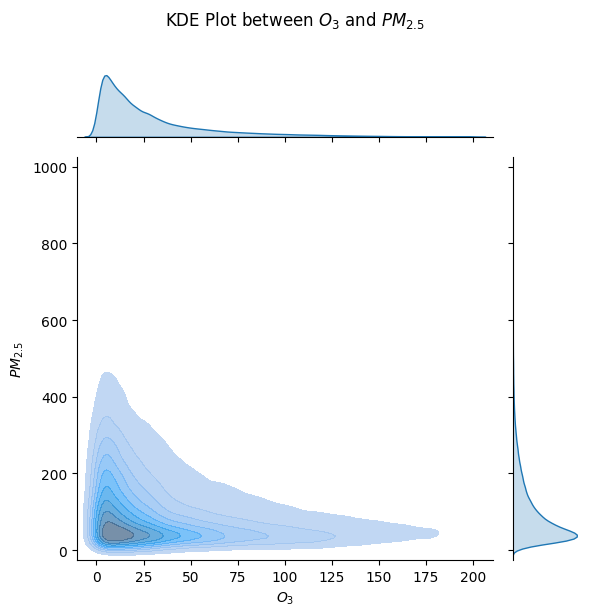

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib as plt
# Assuming `data` is your DataFrame loaded from the CSV file
file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
data = pd.read_csv(file_path)

# Create the KDE plot
kde_fig = sns.jointplot(
    data=data, 
    x="Ozone", 
    y="PM2.5", 
    kind='kde', 
    fill=True, 
    hue=None,  # Add hue if you have a categorical variable for color separation
    joint_kws={'alpha': 0.7}
)

# Customize labels
kde_fig.ax_joint.set_xlabel('$O_3$')
kde_fig.ax_joint.set_ylabel('$PM_{2.5}$')

# Show the plot
kde_fig.fig.suptitle('KDE Plot between $O_3$ and $PM_{2.5}$', y=1.02)  # Adjust title position
kde_fig.fig.tight_layout()
plt.show()